# WhiteAway E-commerce Sales Analysis

## Project Overview

This project analyzes e-commerce sales data to explore sales performance, revenue, profitability, product performance, and differences across shops and countries.

The analysis includes data cleaning, data integration, currency conversion, exploratory data analysis, and business-oriented insights.

### Objectives

- Clean and prepare the sales and product datasets
- Combine information from multiple data sources
- Convert prices and costs into EUR
- Analyze sales, revenue, and profitability
- Identify top-performing products and shops
- Explore product categories and assortment performance

### Tools & Technologies

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- Data Cleaning
- Exploratory Data Analysis

In [2]:
import pandas as pd



## 1. Data Loading and Cleaning

#### Cleaning online sales

In [3]:
df_on_sal= pd.read_csv("online_sales.csv")


In [77]:
df_on_sal['date'] = pd.to_datetime(df_on_sal[['day','month','year']])

In [78]:
df_on_sal.drop(columns=['year', 'month', 'day'], errors='ignore' , inplace = True)
df_on_sal

,payload_orderid,payload_shopcontext,payload_shopshortname,name,sku,type,categoryid,quantity,price,priceinclvat,date
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28
1,152099735,bilka.whiteaway.dk,BILKA,Levering til kantsten,204,FRAGT,NaN,1,279.2,349.0,2026-03-28
2,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,2026-03-28
3,152099736,bilka.whiteaway.dk,BILKA,Levering til kantsten,204,FRAGT,NaN,1,279.2,349.0,2026-03-28
4,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,2026-03-28
...,...,...,...,...,...,...,...,...,...,...,...
346737,200023161,whiteaway.se,SE,Bosch WGB256AWSN Serie 8,WGB256AWSN,MDA,111401.0,1,8796.0,10995.0,2026-02-16
346738,200023161,whiteaway.se,SE,Leverans till tomtgräns/port,204,FRAGT,NaN,1,0.0,0.0,2026-02-16
346739,200023161,whiteaway.se,SE,Försäkring,FORSIKRING,FORSIKRING,NaN,1,309.0,309.0,2026-02-16
346740,200023160,whiteaway.se,SE,Samsung MS23K3523AS,MS23K3523AS,SDA,111102.0,1,1112.0,1390.0,2026-02-16


In [79]:
df_on_sal.columns = [
    'order_id',
    'shop',
    'shop_short_name',
    'name',
    'sku',
    'type',
    'categoryid',
    'quantity',
    'price',
    'priceInclvat',
    'date',
]


In [80]:
df_on_sal.head(5)

,order_id,shop,shop_short_name,name,sku,type,categoryid,quantity,price,priceInclvat,date
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28
1,152099735,bilka.whiteaway.dk,BILKA,Levering til kantsten,204,FRAGT,NaN,1,279.2,349.0,2026-03-28
2,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,2026-03-28
3,152099736,bilka.whiteaway.dk,BILKA,Levering til kantsten,204,FRAGT,NaN,1,279.2,349.0,2026-03-28
4,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,2026-03-28


In [81]:
df_on_sal_clean = df_on_sal.copy()

In [82]:
df_on_sal_clean = df_on_sal_clean[
    ~df_on_sal_clean['type'].isin(['FRAGT', 'FORSIKRING'])
] #focusing only on product

In [83]:
#removing presernt card
df_on_sal_clean= df_on_sal_clean[
 ~df_on_sal_clean["name"].str.contains("Presentkort", case = False, na = False)
]

In [84]:
df_on_sal_clean

,order_id,shop,shop_short_name,name,sku,type,categoryid,quantity,price,priceInclvat,date
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28
2,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,2026-03-28
4,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,2026-03-28
6,152099738,bilka.whiteaway.dk,BILKA,Gorenje NRK619CAW4,NRK619CAW4,MDA,110703.0,1,4172.0,5215.0,2026-03-28
8,152099738,bilka.whiteaway.dk,BILKA,Blomberg BW104LA54W,BW104LA54W,MDA,111401.0,1,3839.2,4799.0,2026-03-28
...,...,...,...,...,...,...,...,...,...,...,...
346731,200023156,whiteaway.se,SE,Nutribullet PRO NB907MAB,NB907MAB,SDA,120401.0,1,692.8,866.0,2026-02-16
346733,200023158,whiteaway.se,SE,Samsung MS23K3523AS,MS23K3523AS,SDA,111102.0,1,1112.0,1390.0,2026-02-16
346735,200023157,whiteaway.se,SE,Miele DAS2620,DAS2620,MDA,110206.0,1,4316.0,5395.0,2026-02-16
346737,200023161,whiteaway.se,SE,Bosch WGB256AWSN Serie 8,WGB256AWSN,MDA,111401.0,1,8796.0,10995.0,2026-02-16


In [85]:
df_on_sal_clean.isnull().sum()

order_id              0
shop                  0
shop_short_name       0
name                  0
sku                   0
type                  0
categoryid         9106
quantity              0
price                 0
priceInclvat          0
date                  0
dtype: int64

In [86]:
df_on_sal_clean['categoryid'] = df_on_sal_clean['categoryid'].fillna(0)
df_on_sal_clean

,order_id,shop,shop_short_name,name,sku,type,categoryid,quantity,price,priceInclvat,date
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28
2,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,2026-03-28
4,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,2026-03-28
6,152099738,bilka.whiteaway.dk,BILKA,Gorenje NRK619CAW4,NRK619CAW4,MDA,110703.0,1,4172.0,5215.0,2026-03-28
8,152099738,bilka.whiteaway.dk,BILKA,Blomberg BW104LA54W,BW104LA54W,MDA,111401.0,1,3839.2,4799.0,2026-03-28
...,...,...,...,...,...,...,...,...,...,...,...
346731,200023156,whiteaway.se,SE,Nutribullet PRO NB907MAB,NB907MAB,SDA,120401.0,1,692.8,866.0,2026-02-16
346733,200023158,whiteaway.se,SE,Samsung MS23K3523AS,MS23K3523AS,SDA,111102.0,1,1112.0,1390.0,2026-02-16
346735,200023157,whiteaway.se,SE,Miele DAS2620,DAS2620,MDA,110206.0,1,4316.0,5395.0,2026-02-16
346737,200023161,whiteaway.se,SE,Bosch WGB256AWSN Serie 8,WGB256AWSN,MDA,111401.0,1,8796.0,10995.0,2026-02-16


In [87]:
df_on_sal_clean.duplicated().sum()

np.int64(6000)

In [88]:
df_on_sal_clean = df_on_sal_clean[
    ~df_on_sal_clean['shop'].isin(['skousenos.dk', 'skousen.se'])
]

## 2. Product Data

In [5]:
df_pro= pd.read_csv("product_info.csv")

In [6]:
df_pro.head()

,sku,product_name,shop,category_id,category_name,priceexclvat,priceinclvat,unitcostonline,stock_location,quantity,date_available,gen_prod_posting_group,assortment
0,RCSA366K40WN,Beko RCSA366K40WN,FOETEX,110703,Fritstående køle-fryseskabe,6399.2,7999.0,2251.50,LOG-PCN,92,2025-09-18 00:00:00.000000,MDA,1
1,MG7Z2593B,LG MG7Z2593B,FOETEX,111103,Indbygningsmikrobølgeovne,4799.2,5999.0,1530.05,LOG-PCN,86,2026-01-27 00:00:00.000000,MDA,1
2,YT971.1000.70,Silverline kulfilter 10,TRETNO,110299,Tilbehør til ventilatorer,632.0,790.0,409.31,LOG-PCN,0,2015-10-23 00:00:00.000000,SDA,2
3,535.21.3031.9,Thermex KF 80 - kulfiltersæt,ENEMO,110299,Tillbehör till köksfläktar,959.2,1199.0,906.33,NaN,0,NaN,SDA,2
4,EICO-6330,EICO Era 80 Grey,SKOUNO,110204,Innebygde ventilatorer,1999.2,2499.0,2009.71,LOG-PCN,0,2024-05-03 00:00:00.000000,MDA,2


## 3. Handling Missing Product Information

In [7]:
df_missing_pro = pd.read_csv("missing_product_info.csv")
df_missing_pro

,sku,product_name,shop,category_id,category_name,priceexclvat,priceinclvat,unitcostonline,quantity,date_available,gen_prod_posting_group,assortment
0,535.42.9160.9,Thermex KF60,FOETEX,1.102990e+05,Tilbehør til emhætter,292.0,365.0,218.89,6,NaN,SDA,2
1,540.23.1668.0,Thermex Mini Preston II 600,FOETEX,1.102070e+05,Væghængte emhætter,9596.0,11995.0,4253.72,0,NaN,MDA,9
2,540.23.1668.2,Thermex Mini Preston II 60 cm Sort m/motor (ESP),FOETEX,1.102070e+05,Væghængte emhætter,11116.0,13895.0,3951.03,0,NaN,MDA,9
3,CCE3T618EB,Candy CCE3T618EB,FOETEX,1.107030e+05,Fritstående køle-fryseskabe,5999.2,7499.0,2324.69,0,NaN,MDA,9
4,CI100EU,Ninja CI100EU 3-in-1 Blender Set,FOETEX,NaN,NaN,799.2,999.0,659.47,51,2026-05-13 00:00:00.000000,SDA,1
...,...,...,...,...,...,...,...,...,...,...,...,...
11250,CB-140766-X4,*Char-Broil Overtræk til grill med 3-4 brænde...,DK,1.802031e+09,Tilbehør til grill,1596.8,1996.0,637.33,50,2026-03-03 00:00:00.000000,SDA,10
11251,DI2788,Dreame Multi-Surface Floor Cleaner 1L,DK,1.112990e+05,Tilbehør til støvsuger,151.2,189.0,119.43,0,NaN,SDA,6
11252,B789SILENCEEE,Bauknecht B789SILENCEEE,DK,1.114010e+05,Frontbetjente vaskemaskiner,8796.0,10995.0,2180.49,0,2026-03-12 00:00:00.000000,MDA,6
11253,B899ADSILENCEE,Bauknecht B899ADSILENCEE,DK,1.114010e+05,Frontbetjente vaskemaskiner,9596.0,11995.0,2378.33,0,2026-03-12 00:00:00.000000,MDA,6


### Combining Product Datasets

In [92]:

# Combine with existing product info
df_pro_comb = pd.concat([df_missing_pro, df_pro], ignore_index=True)
df_pro_comb

,sku,product_name,shop,category_id,category_name,priceexclvat,priceinclvat,unitcostonline,quantity,date_available,gen_prod_posting_group,assortment,stock_location
0,535.42.9160.9,Thermex KF60,FOETEX,110299.0,Tilbehør til emhætter,292.0,365.0,218.89,6,NaN,SDA,2,NaN
1,540.23.1668.0,Thermex Mini Preston II 600,FOETEX,110207.0,Væghængte emhætter,9596.0,11995.0,4253.72,0,NaN,MDA,9,NaN
2,540.23.1668.2,Thermex Mini Preston II 60 cm Sort m/motor (ESP),FOETEX,110207.0,Væghængte emhætter,11116.0,13895.0,3951.03,0,NaN,MDA,9,NaN
3,CCE3T618EB,Candy CCE3T618EB,FOETEX,110703.0,Fritstående køle-fryseskabe,5999.2,7499.0,2324.69,0,NaN,MDA,9,NaN
4,CI100EU,Ninja CI100EU 3-in-1 Blender Set,FOETEX,NaN,NaN,799.2,999.0,659.47,51,2026-05-13 00:00:00.000000,SDA,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57178,FAB10HRPG6,SMEG Smeg FAB10HRPG6,TRETSE,110801.0,Fristående kylskåp,9268.0,11585.0,9267.62,0,NaN,MDA,2,NaN
57179,KGE398IBP,Bosch KGE398IBP Serie 6,SE,110703.0,Fristående kyl-frysar,13836.0,17295.0,13251.99,-100,NaN,MDA,2,ESK
57180,H2455BOBSW,Miele H2455BOBSW,SKOU,111002.0,Indbygningsovne,5436.0,6795.0,3836.90,5,2026-03-23 00:00:00.000000,MDA,1,LOG-PCN
57181,MIN64608N,Blomberg MIN64608N,DK,110504.0,Induktionskogeplader,5999.2,7499.0,2244.70,95,2025-10-03 00:00:00.000000,MDA,1,LOG-PCN


In [93]:
df_pro_comb.duplicated().sum()

np.int64(1)

In [94]:
df_pro_comb[df_pro_comb.duplicated(keep=False)]

,sku,product_name,shop,category_id,category_name,priceexclvat,priceinclvat,unitcostonline,quantity,date_available,gen_prod_posting_group,assortment,stock_location
11097,KJGN-3,JGNordic KJGN-3,DK,110299.0,Tilbehør til emhætter,2162.4,2703.0,1297.5,0,2026-04-30 00:00:00.000000,SDA,10,NaN
42699,KJGN-3,JGNordic KJGN-3,DK,110299.0,Tilbehør til emhætter,2162.4,2703.0,1297.5,0,2026-04-30 00:00:00.000000,SDA,10,NaN


In [95]:
df_pro_comb = df_pro_comb.drop_duplicates()

## 4. Website and Country Mapping

In [8]:
df_map= pd.read_csv("websites_name_mapping.csv")
df_map

,navision_company,hq_company,website,shopshortname,country,short_hostname
0,A Hvidevare,whiteaway,www.whiteaway.com,DK,DK,whiteaway.com
1,Enemo Sverige,enemo_se,www.enemo.se,ENEMO,SE,enemo.se
2,Lavpris Hvidevarer,lavprishvidevarer_dk,www.lavprishvidevarer.dk,LPH,DK,lavprishvidevarer.dk
3,SG Bilka,hvidevarer_bilka_dk,bilka.whiteaway.dk,BILKA,DK,bilka.whiteaway.dk
4,SG Føtex,hvidevarer_foetex_dk,foetex.whiteaway.dk,FOETEX,DK,foetex.whiteaway.dk
5,SG Wupti,hvidevarer_wupti_com,NaN,WUPTI,DK,NaN
6,SOS,whiteaway_red,www.skousen.dk,SKOU,DK,skousen.dk
7,Skousen Norge,skousen_no,www.skousen.no,SKOUNO,NO,skousen.no
8,Tretti NO,tretti_no,www.tretti.no,TRETNO,NO,tretti.no
9,Tretti SE,tretti_se,www.tretti.se,TRETSE,SE,tretti.se


In [97]:
df_map[df_map.isnull().any(axis=1)]

,navision_company,hq_company,website,shopshortname,country,short_hostname
5,SG Wupti,hvidevarer_wupti_com,NaN,WUPTI,DK,NaN


In [98]:
df_map.fillna("unknown" , inplace = True)

,navision_company,hq_company,website,shopshortname,country,short_hostname
0,A Hvidevare,whiteaway,www.whiteaway.com,DK,DK,whiteaway.com
1,Enemo Sverige,enemo_se,www.enemo.se,ENEMO,SE,enemo.se
2,Lavpris Hvidevarer,lavprishvidevarer_dk,www.lavprishvidevarer.dk,LPH,DK,lavprishvidevarer.dk
3,SG Bilka,hvidevarer_bilka_dk,bilka.whiteaway.dk,BILKA,DK,bilka.whiteaway.dk
4,SG Føtex,hvidevarer_foetex_dk,foetex.whiteaway.dk,FOETEX,DK,foetex.whiteaway.dk
5,SG Wupti,hvidevarer_wupti_com,unknown,WUPTI,DK,unknown
6,SOS,whiteaway_red,www.skousen.dk,SKOU,DK,skousen.dk
7,Skousen Norge,skousen_no,www.skousen.no,SKOUNO,NO,skousen.no
8,Tretti NO,tretti_no,www.tretti.no,TRETNO,NO,tretti.no
9,Tretti SE,tretti_se,www.tretti.se,TRETSE,SE,tretti.se


## 5. Merging Sales Data with Website Mapping

In [99]:
merged_sales_map = pd.merge(
    df_on_sal_clean,
    df_map[['shopshortname', 'country']],
    left_on='shop_short_name',
    right_on='shopshortname',
    how='left'
)
merged_sales_map.head()

,order_id,shop,shop_short_name,name,sku,type,categoryid,quantity,price,priceInclvat,date,shopshortname,country
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28,BILKA,DK
1,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,2026-03-28,BILKA,DK
2,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,2026-03-28,BILKA,DK
3,152099738,bilka.whiteaway.dk,BILKA,Gorenje NRK619CAW4,NRK619CAW4,MDA,110703.0,1,4172.0,5215.0,2026-03-28,BILKA,DK
4,152099738,bilka.whiteaway.dk,BILKA,Blomberg BW104LA54W,BW104LA54W,MDA,111401.0,1,3839.2,4799.0,2026-03-28,BILKA,DK


In [100]:
merged_sales_map['country'].isnull().sum()

np.int64(0)

In [101]:
merged_sales_map.isnull().sum()

order_id           0
shop               0
shop_short_name    0
name               0
sku                0
type               0
categoryid         0
quantity           0
price              0
priceInclvat       0
date               0
shopshortname      0
country            0
dtype: int64

In [102]:
# euro rate dictionary
rates = {
    'DK': 7.4707,
    'SE': 10.6947,
    'NO': 11.3820
}
merged_sales_map['rates'] = merged_sales_map['country'].map(rates) # assigning the rate to particular countries

In [103]:
merged_sales_map['rates'].isnull().sum()

np.int64(0)

In [104]:
merged_sales_map['price_eur']= (merged_sales_map['price']/merged_sales_map['rates']).round(3)
merged_sales_map.head()

,order_id,shop,shop_short_name,name,sku,type,categoryid,quantity,price,priceInclvat,date,shopshortname,country,rates,price_eur
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28,BILKA,DK,7.4707,356.914
1,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,2026-03-28,BILKA,DK,7.4707,267.605
2,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,2026-03-28,BILKA,DK,7.4707,428.233
3,152099738,bilka.whiteaway.dk,BILKA,Gorenje NRK619CAW4,NRK619CAW4,MDA,110703.0,1,4172.0,5215.0,2026-03-28,BILKA,DK,7.4707,558.448
4,152099738,bilka.whiteaway.dk,BILKA,Blomberg BW104LA54W,BW104LA54W,MDA,111401.0,1,3839.2,4799.0,2026-03-28,BILKA,DK,7.4707,513.901


In [105]:
merged_sales_map['shop'].value_counts()

shop
tretti.se               41652
skousen.dk              40825
skousen.no              24959
whiteaway.com           17905
whiteaway.se             7784
whiteaway.no             5406
bilka.whiteaway.dk       3821
lavprishvidevarer.dk     1922
enemo.se                 1407
tretti.no                1140
foetex.whiteaway.dk       199
Name: count, dtype: int64

## 6. Merging Sales with Product Data

In [106]:
merged_sales_map

,order_id,shop,shop_short_name,name,sku,type,categoryid,quantity,price,priceInclvat,date,shopshortname,country,rates,price_eur
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28,BILKA,DK,7.4707,356.914
1,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,2026-03-28,BILKA,DK,7.4707,267.605
2,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,2026-03-28,BILKA,DK,7.4707,428.233
3,152099738,bilka.whiteaway.dk,BILKA,Gorenje NRK619CAW4,NRK619CAW4,MDA,110703.0,1,4172.0,5215.0,2026-03-28,BILKA,DK,7.4707,558.448
4,152099738,bilka.whiteaway.dk,BILKA,Blomberg BW104LA54W,BW104LA54W,MDA,111401.0,1,3839.2,4799.0,2026-03-28,BILKA,DK,7.4707,513.901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147015,200023156,whiteaway.se,SE,Nutribullet PRO NB907MAB,NB907MAB,SDA,120401.0,1,692.8,866.0,2026-02-16,SE,SE,10.6947,64.780
147016,200023158,whiteaway.se,SE,Samsung MS23K3523AS,MS23K3523AS,SDA,111102.0,1,1112.0,1390.0,2026-02-16,SE,SE,10.6947,103.977
147017,200023157,whiteaway.se,SE,Miele DAS2620,DAS2620,MDA,110206.0,1,4316.0,5395.0,2026-02-16,SE,SE,10.6947,403.564
147018,200023161,whiteaway.se,SE,Bosch WGB256AWSN Serie 8,WGB256AWSN,MDA,111401.0,1,8796.0,10995.0,2026-02-16,SE,SE,10.6947,822.463


In [107]:
df_pro_comb

,sku,product_name,shop,category_id,category_name,priceexclvat,priceinclvat,unitcostonline,quantity,date_available,gen_prod_posting_group,assortment,stock_location
0,535.42.9160.9,Thermex KF60,FOETEX,110299.0,Tilbehør til emhætter,292.0,365.0,218.89,6,NaN,SDA,2,NaN
1,540.23.1668.0,Thermex Mini Preston II 600,FOETEX,110207.0,Væghængte emhætter,9596.0,11995.0,4253.72,0,NaN,MDA,9,NaN
2,540.23.1668.2,Thermex Mini Preston II 60 cm Sort m/motor (ESP),FOETEX,110207.0,Væghængte emhætter,11116.0,13895.0,3951.03,0,NaN,MDA,9,NaN
3,CCE3T618EB,Candy CCE3T618EB,FOETEX,110703.0,Fritstående køle-fryseskabe,5999.2,7499.0,2324.69,0,NaN,MDA,9,NaN
4,CI100EU,Ninja CI100EU 3-in-1 Blender Set,FOETEX,NaN,NaN,799.2,999.0,659.47,51,2026-05-13 00:00:00.000000,SDA,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57178,FAB10HRPG6,SMEG Smeg FAB10HRPG6,TRETSE,110801.0,Fristående kylskåp,9268.0,11585.0,9267.62,0,NaN,MDA,2,NaN
57179,KGE398IBP,Bosch KGE398IBP Serie 6,SE,110703.0,Fristående kyl-frysar,13836.0,17295.0,13251.99,-100,NaN,MDA,2,ESK
57180,H2455BOBSW,Miele H2455BOBSW,SKOU,111002.0,Indbygningsovne,5436.0,6795.0,3836.90,5,2026-03-23 00:00:00.000000,MDA,1,LOG-PCN
57181,MIN64608N,Blomberg MIN64608N,DK,110504.0,Induktionskogeplader,5999.2,7499.0,2244.70,95,2025-10-03 00:00:00.000000,MDA,1,LOG-PCN


In [108]:
print('Sales shops:', merged_sales_map['shop_short_name'].unique())
print('Product shops:', df_pro_comb['shop'].unique())

Sales shops: <StringArray>
[ 'BILKA',  'ENEMO', 'FOETEX',    'LPH',   'SKOU', 'SKOUNO', 'TRETNO',
 'TRETSE',     'DK',     'NO',     'SE']
Length: 11, dtype: str
Product shops: <StringArray>
['FOETEX',  'BILKA',  'ENEMO', 'TRETNO',    'LPH', 'SKOUNO',     'SE',
     'NO', 'TRETSE',   'SKOU',     'DK']
Length: 11, dtype: str


In [109]:
merged_final = pd.merge(
    merged_sales_map,
    df_pro_comb[['sku', 'shop', 'unitcostonline', 'category_name', 'assortment']],
    left_on=['sku', 'shop_short_name'],
    right_on=['sku', 'shop'],
    how='left'
)

print(merged_final.shape)
print('Nulls in unitcostonline:', merged_final['unitcostonline'].isnull().sum())

(156005, 19)
Nulls in unitcostonline: 892


In [110]:
merged_final['unitcostonline_eur'] = (merged_final['unitcostonline'] / merged_final['rates']).round(3)

In [111]:
merged_final.head()

,order_id,shop_x,shop_short_name,name,sku,type,categoryid,quantity,price,priceInclvat,date,shopshortname,country,rates,price_eur,shop_y,unitcostonline,category_name,assortment,unitcostonline_eur
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28,BILKA,DK,7.4707,356.914,BILKA,2433.46,Frontbetjente vaskemaskiner,1,325.734
1,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,2026-03-28,BILKA,DK,7.4707,356.914,BILKA,2433.46,Frontbetjente vaskemaskiner,1,325.734
2,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,2026-03-28,BILKA,DK,7.4707,267.605,BILKA,1612.10,Vinkøleskabe,1,215.790
3,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,2026-03-28,BILKA,DK,7.4707,428.233,BILKA,3528.40,Fritstående fryseskab,1,472.298
4,152099738,bilka.whiteaway.dk,BILKA,Gorenje NRK619CAW4,NRK619CAW4,MDA,110703.0,1,4172.0,5215.0,2026-03-28,BILKA,DK,7.4707,558.448,BILKA,2920.69,Fritstående køle-fryseskabe,1,390.953


In [112]:
merged_final.duplicated().sum()

np.int64(8475)

In [113]:
merged_final = merged_final.drop_duplicates()


In [114]:
merged_final.isnull().sum()

order_id                 0
shop_x                   0
shop_short_name          0
name                     0
sku                      0
type                     0
categoryid               0
quantity                 0
price                    0
priceInclvat             0
date                     0
shopshortname            0
country                  0
rates                    0
price_eur                0
shop_y                 850
unitcostonline         850
category_name         9937
assortment             905
unitcostonline_eur     850
dtype: int64

In [115]:
merged_final.columns

Index(['order_id', 'shop_x', 'shop_short_name', 'name', 'sku', 'type',
       'categoryid', 'quantity', 'price', 'priceInclvat', 'date',
       'shopshortname', 'country', 'rates', 'price_eur', 'shop_y',
       'unitcostonline', 'category_name', 'assortment', 'unitcostonline_eur'],
      dtype='str')

In [116]:
merged_final['unitcostonline'] = merged_final['unitcostonline'].fillna(0)

In [117]:
merged_final['unitcostonline_eur'] = merged_final['unitcostonline_eur'].fillna(0)


In [118]:
merged_final['revenue_eur'] = (merged_final['price_eur'] * merged_final['quantity']).round(3)
merged_final['profit_eur'] = ((merged_final['price_eur'] - merged_final['unitcostonline_eur']) * merged_final['quantity']).round(3)

In [119]:
merged_final

,order_id,shop_x,shop_short_name,name,sku,type,categoryid,quantity,price,priceInclvat,...,country,rates,price_eur,shop_y,unitcostonline,category_name,assortment,unitcostonline_eur,revenue_eur,profit_eur
0,152099735,bilka.whiteaway.dk,BILKA,LG F4Y5EYP6W0F,F4Y5EYP6W0F,MDA,111401.0,1,2666.4,3333.0,...,DK,7.4707,356.914,BILKA,2433.46,Frontbetjente vaskemaskiner,1,325.734,356.914,31.180
2,152099736,bilka.whiteaway.dk,BILKA,Witt Classic EF5483I-1B48,WITT-15482600,MDA,1115.0,1,1999.2,2499.0,...,DK,7.4707,267.605,BILKA,1612.10,Vinkøleskabe,1,215.790,267.605,51.815
3,152099737,bilka.whiteaway.dk,BILKA,LG GFE61SWCSZ,GFE61SWCSZ,MDA,110301.0,1,3199.2,3999.0,...,DK,7.4707,428.233,BILKA,3528.40,Fritstående fryseskab,1,472.298,428.233,-44.065
4,152099738,bilka.whiteaway.dk,BILKA,Gorenje NRK619CAW4,NRK619CAW4,MDA,110703.0,1,4172.0,5215.0,...,DK,7.4707,558.448,BILKA,2920.69,Fritstående køle-fryseskabe,1,390.953,558.448,167.495
5,152099738,bilka.whiteaway.dk,BILKA,Blomberg BW104LA54W,BW104LA54W,MDA,111401.0,1,3839.2,4799.0,...,DK,7.4707,513.901,BILKA,2837.45,Frontbetjente vaskemaskiner,1,379.810,513.901,134.091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156000,200023156,whiteaway.se,SE,Nutribullet PRO NB907MAB,NB907MAB,SDA,120401.0,1,692.8,866.0,...,SE,10.6947,64.780,SE,694.01,Blenders,1,64.893,64.780,-0.113
156001,200023158,whiteaway.se,SE,Samsung MS23K3523AS,MS23K3523AS,SDA,111102.0,1,1112.0,1390.0,...,SE,10.6947,103.977,SE,1060.44,Fristående mikrovågsugnar,1A,99.156,103.977,4.821
156002,200023157,whiteaway.se,SE,Miele DAS2620,DAS2620,MDA,110206.0,1,4316.0,5395.0,...,SE,10.6947,403.564,SE,4783.11,Utdragbara köksfläktar,1,447.241,403.564,-43.677
156003,200023161,whiteaway.se,SE,Bosch WGB256AWSN Serie 8,WGB256AWSN,MDA,111401.0,1,8796.0,10995.0,...,SE,10.6947,822.463,SE,8717.51,Frontmatade tvättmaskiner,1,815.124,822.463,7.339


## 7. Sales and Profitability Analysis

In [120]:
#top 10 sold product
top10_products = (merged_final.groupby(['sku','name'])['quantity'].sum().sort_values(ascending=False).head(10)).reset_index()

top10_products

,sku,name,quantity
0,F4Y5EYP6W0F,LG F4Y5EYP6W0F,1787
1,E201SM,Electrolux S-bag 12x E201SM,1322
2,F4A1009NWK,LG F4A1009NWK,1299
3,EB51C2GG,Electrolux EB51C2GG,1212
4,AURO-352219,4stk Vibrationsdämpare,1000
5,AURO-352219,Gummifødder sæt á 4 stk,818
6,AURO-7662636,Droppskydd 60cm diskmaskin,794
7,PD82-GREEN,Electrolux PD82-GREEN,792
8,MI-12557080,CO HyClean Pure,780
9,BCHF216B,Bosch BCHF216B,760


In [121]:
import matplotlib.pyplot as plt

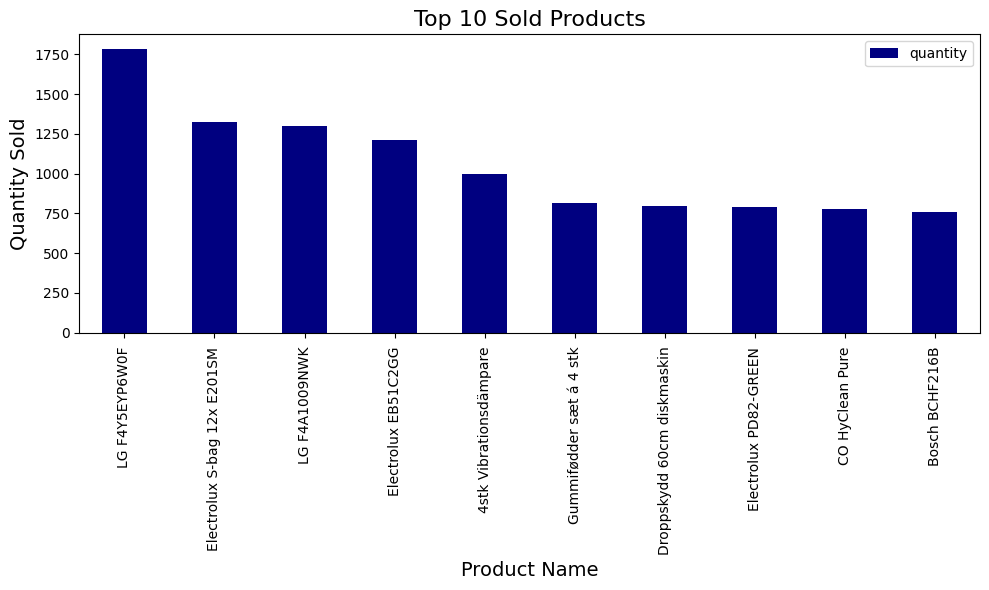

In [122]:
top10_products.plot(kind='bar', x='name', figsize=(10, 6), color='navy')
plt.title('Top 10 Sold Products', fontsize=16)
plt.xlabel('Product Name', fontsize=14)
plt.ylabel('Quantity Sold', fontsize=14)
plt.tight_layout()
plt.show()

In [123]:
#top 10 revenue by shop
top10_rev_shop= merged_final.groupby('shop_x')['revenue_eur'].sum().round(2).sort_values(ascending=False).head(10)
top10_rev_shop

shop_x
tretti.se               15249866.18
skousen.dk              10231669.15
skousen.no               9741487.30
whiteaway.com            5307084.50
whiteaway.se             2283872.40
whiteaway.no             1724539.94
bilka.whiteaway.dk       1649363.61
lavprishvidevarer.dk      424213.08
enemo.se                  372038.54
tretti.no                 279925.82
Name: revenue_eur, dtype: float64

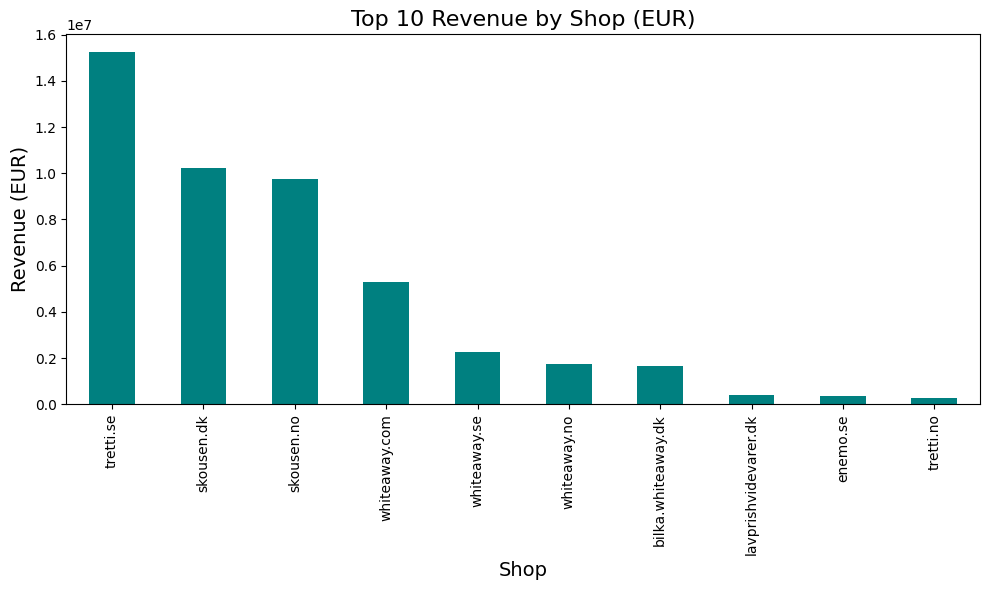

In [124]:
top10_rev_shop.plot(kind='bar', figsize=(10, 6), color='teal')
plt.title('Top 10 Revenue by Shop (EUR)', fontsize=16)
plt.xlabel('Shop', fontsize=14)
plt.ylabel('Revenue (EUR)', fontsize=14)
plt.tight_layout()
plt.show()

In [125]:
#top 10 revenue by product
top10_rev_pro = merged_final.groupby('name')['revenue_eur'].sum().round(2).sort_values(ascending=False).head(10)
top10_rev_pro

name
LG F4Y5EYP6W0F                       680868.81
Samsung RR39C7BG7S9 & RZ32C7BF6S9    447989.84
Siemens HB774G2B3S iQ700             417829.28
LG F4A1009NWK                        384084.60
Siemens ED811HQ26E iQ500             378282.45
LG F4Y5EYP6W0F & RH90V5AV7N          330275.37
LG F4Y5VRP6WY                        328081.76
Siemens HB776G3B1S iQ700             282245.47
Siemens SX75ZX07CE iQ500             270206.16
Siemens HB571ABS3  iQ300             247015.54
Name: revenue_eur, dtype: float64

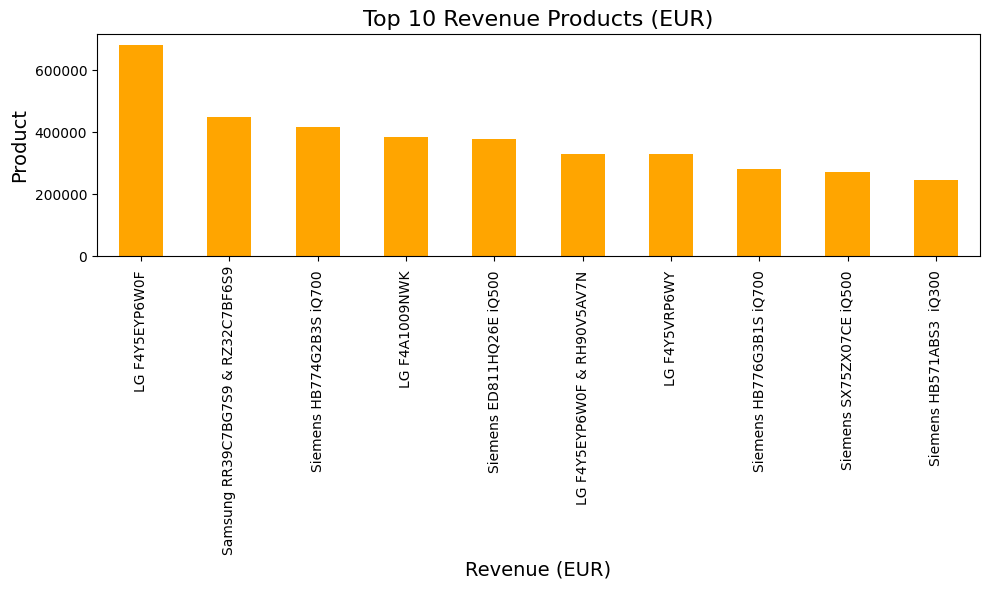

In [126]:
top10_rev_pro.plot(kind='bar', figsize=(10, 6), color='orange')
plt.title('Top 10 Revenue Products (EUR)', fontsize=16)
plt.xlabel('Revenue (EUR)', fontsize=14)
plt.ylabel('Product', fontsize=14)
plt.tight_layout()
plt.show()

In [127]:
#top 10 profit by shop
top10_profit_shop= merged_final.groupby('shop_x')['profit_eur'].sum().sort_values(ascending=False).head(10)
top10_profit_shop

shop_x
tretti.se               918777.892
skousen.dk              795716.664
whiteaway.com           491682.959
skousen.no              314828.295
whiteaway.se            181114.288
whiteaway.no            157057.466
bilka.whiteaway.dk      133974.598
lavprishvidevarer.dk     38376.274
enemo.se                 36688.725
tretti.no                33477.685
Name: profit_eur, dtype: float64

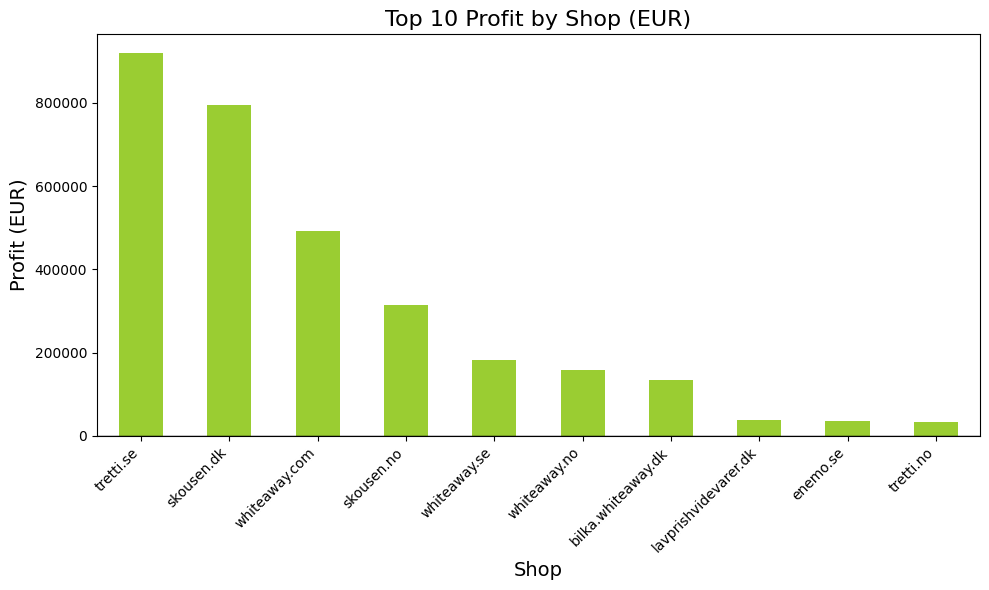

In [128]:
top10_profit_shop.plot(kind='bar', figsize=(10, 6), color='yellowgreen')
plt.title('Top 10 Profit by Shop (EUR)', fontsize=16)
plt.xlabel('Shop', fontsize=14)
plt.axhline(y=0, color='black', linewidth=1)
plt.ylabel('Profit (EUR)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [129]:
#profit by country
profit_coun= merged_final.groupby('country')['profit_eur'].sum().sort_values(ascending=False)
profit_coun

country
DK    1468419.296
SE    1136580.905
NO     505363.446
Name: profit_eur, dtype: float64

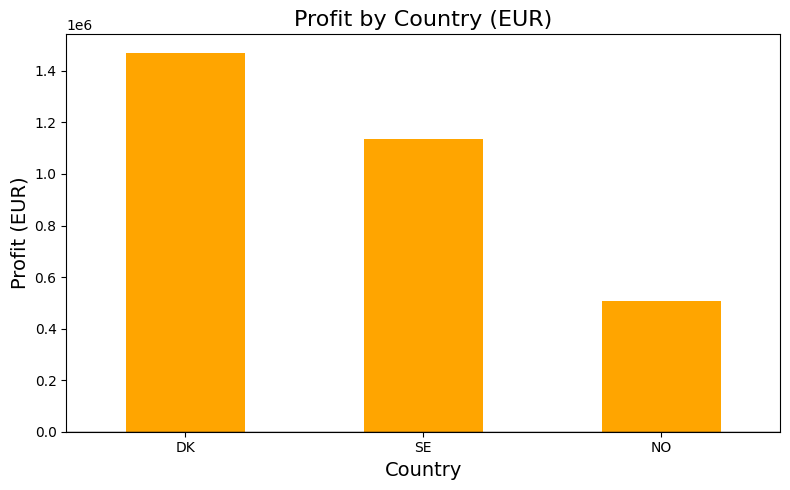

In [130]:
profit_coun.plot(kind='bar', figsize=(8, 5), color='orange')
plt.title('Profit by Country (EUR)', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Profit (EUR)', fontsize=14)
plt.xticks(rotation=0)
plt.axhline(y=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [131]:
#top 10 profit by category
top10_profit_category= merged_final.groupby('category_name')['profit_eur'].sum().sort_values(ascending=False).head(10)
top10_profit_category

category_name
Paketerbjudanden - tvättmaskiner och torktumlare    278249.436
Kyl- och fryspaket                                  136491.866
Frontbetjente vaskemaskiner                         121590.477
Integrerbare opvaskemaskiner                         99678.141
Kondenstørretumblere                                 84785.923
Støvsugere                                           83937.400
Fritstående køle-fryseskabe                          76139.390
Induktionshällar                                     73552.888
Underbyggda diskmaskiner                             70445.568
Dammsugare                                           66905.323
Name: profit_eur, dtype: float64

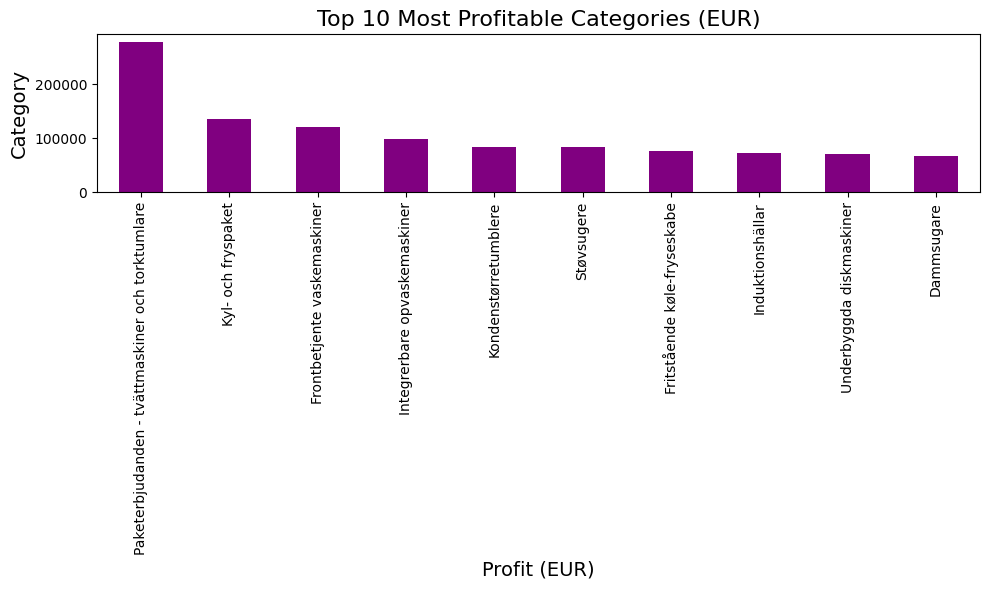

In [132]:
top10_profit_category.plot(kind='bar', figsize=(10, 6), color='purple')
plt.title('Top 10 Most Profitable Categories (EUR)', fontsize=16)
plt.xlabel('Profit (EUR)', fontsize=14)
plt.ylabel('Category', fontsize=14)
plt.tight_layout()
plt.show()

In [133]:
#top 10 profitable product
top10_profitable_pro = (merged_final.groupby(['sku','name'])['profit_eur'].sum()).round(3).sort_values(ascending=False).head(10).reset_index()
top10_profitable_pro

,sku,name,profit_eur
0,F4A10_RHA10_DK,LG F4A1009NDK & RHA1008NDK,63715.464
1,F4Y5EYP6W0F,LG F4Y5EYP6W0F,60989.166
2,ED811HQ26E,Siemens ED811HQ26E iQ500,39155.408
3,F2Y5PRP6W,LG F2Y5PRP6W,32696.194
4,WW90CGC04_DV90DG52A0,Samsung WW90CGC04AAHEN + DV90DG52A0AHEE,30079.833
5,F4X7011TBB,LG F4X7011TBB,29265.887
6,SDU587HV,LG SDU587HV,25940.359
7,SX75ZX16CE,Siemens SX75ZX16CE iQ500,25599.540
8,WES84_DHNE82,Gorenje WES84AS + DHNE82,24349.870
9,WGG244F_WQG242W,Bosch WGG244FWSN & WQG2420WSN,23841.820


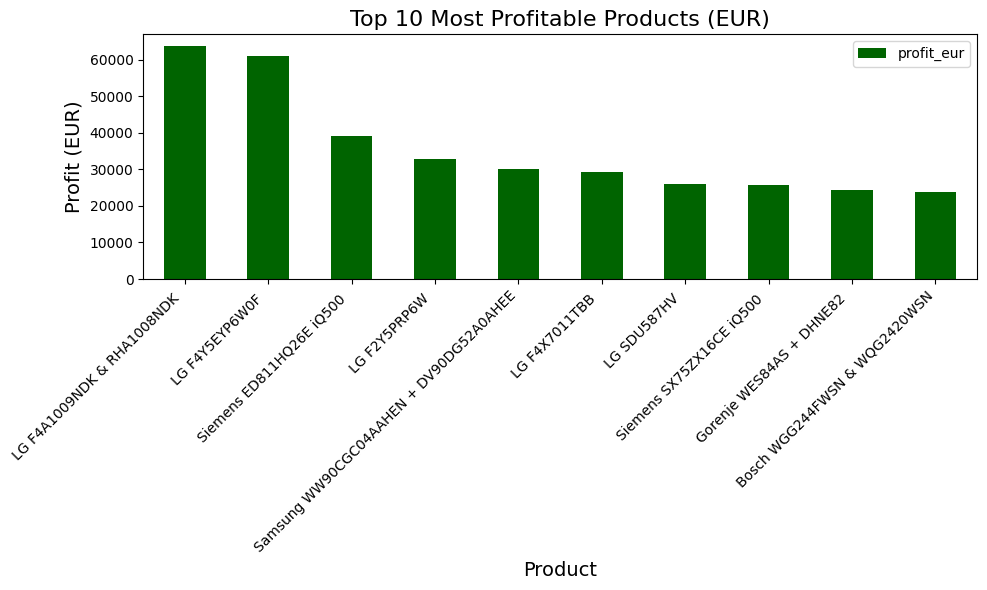

In [134]:
top10_profitable_pro.plot(kind='bar', x='name', y='profit_eur', figsize=(10, 6), color='darkgreen')
plt.title('Top 10 Most Profitable Products (EUR)', fontsize=16)
plt.xlabel('Product', fontsize=14)
plt.ylabel('Profit (EUR)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [135]:
#top 10 least profitable products
top10_least_profit_pro= merged_final.groupby(['sku','name'])['profit_eur'].sum().round(3).sort_values(ascending=True).head(10).reset_index()
top10_least_profit_pro

,sku,name,profit_eur
0,LEVOIT-70805,LEVOIT Levoit Vital 200S Pro Smart HEPA Air P...,-48992.078
1,F4A1009NWK,LG F4A1009NWK,-48735.049
2,EFI621W84W,Electrolux EFI621W84W,-29980.051
3,DYSONV15AB,Dyson V15 Detect Absolute,-28126.613
4,RZ32C7ADEWW,Samsung RZ32C7ADEWW,-20918.947
5,AF500EU,Ninja AF500EU Foodi FlexDrawer,-18576.106
6,SN43HW01VS,Siemens SN43HW01VS iQ300,-15900.894
7,HLN39A020,Bosch HLN39A020 Serie 4,-14179.371
8,BCHF216B,Bosch BCHF216B,-13486.871
9,ESA47305UX,Electrolux ESA47305UX,-12073.412


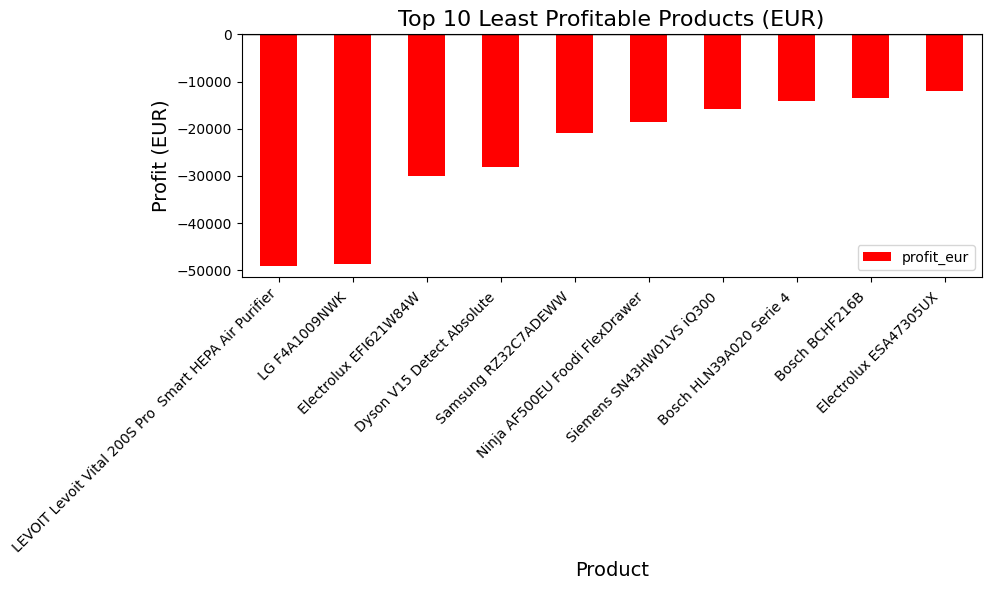

In [136]:
top10_least_profit_pro.plot(kind='bar', x='name', y='profit_eur', figsize=(10, 6), color='red')
plt.title('Top 10 Least Profitable Products (EUR)', fontsize=16)
plt.xlabel('Product',fontsize=14)
plt.ylabel('Profit (EUR)', fontsize=14)
plt.axhline(y=0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Comparing Sales Performance

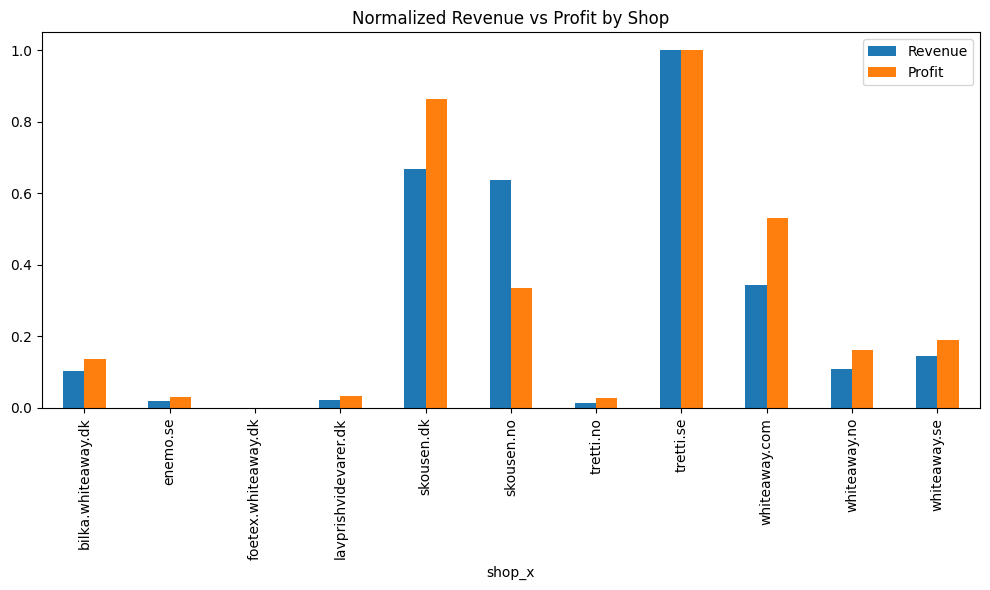

In [137]:
#normalized revenue and profit by shop
combined_norm = pd.DataFrame({
    'Revenue': merged_final.groupby('shop_x')['revenue_eur'].sum(),
    'Profit': merged_final.groupby('shop_x')['profit_eur'].sum()
})

combined_norm = (combined_norm - combined_norm.min()) / (combined_norm.max() - combined_norm.min())

combined_norm.plot(kind='bar', figsize=(10, 6))
plt.title('Normalized Revenue vs Profit by Shop')
plt.tight_layout()
plt.show()

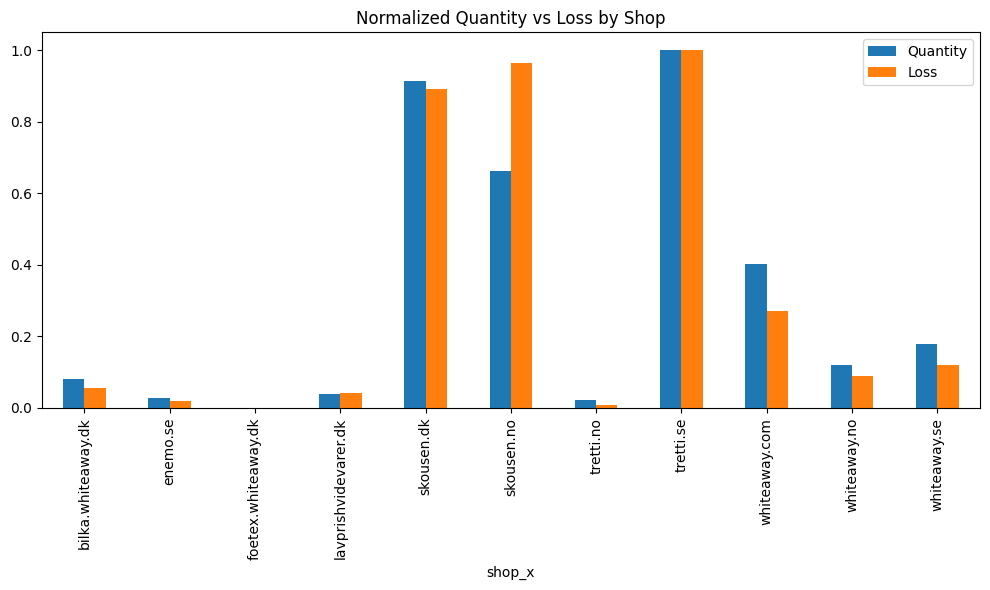

In [138]:
#normalized quantity and loss by shop
combined_norm = pd.DataFrame({
    'Quantity': merged_final.groupby('shop_x')['quantity'].sum(),
    'Loss': merged_final[merged_final['profit_eur'] < 0].groupby('shop_x')['profit_eur'].sum().abs()
})

combined_norm = (combined_norm - combined_norm.min()) / (combined_norm.max() - combined_norm.min())

combined_norm.plot(kind='bar', figsize=(10, 6))
plt.title('Normalized Quantity vs Loss by Shop')
plt.tight_layout()
plt.show()

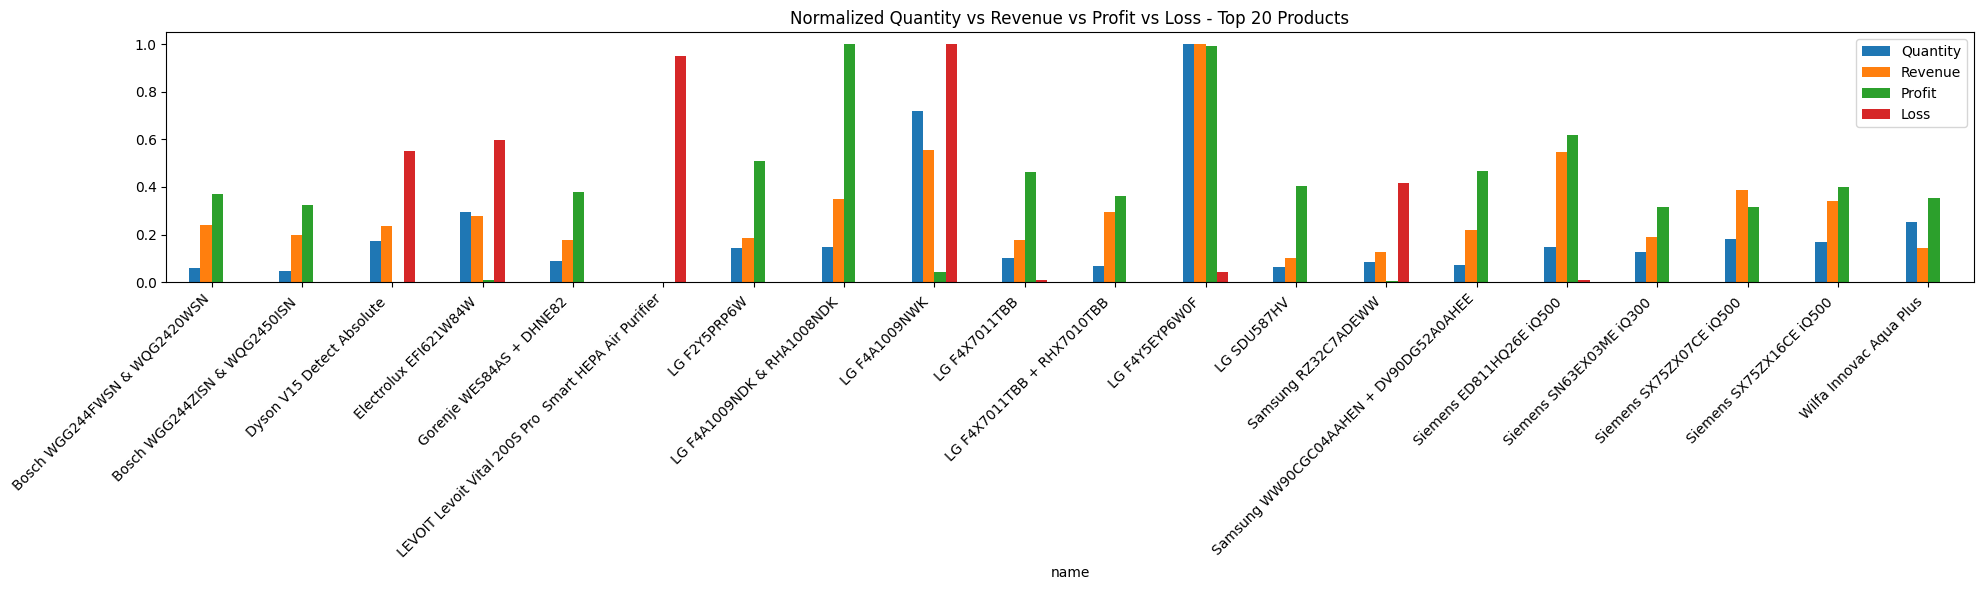

In [139]:
#normalized quantity vs revenue vs profit for top 20 products
top20_products = merged_final.groupby('name')['profit_eur'].sum().abs().sort_values(ascending=False).head(20).index

combined_norm = pd.DataFrame({
    'Quantity': merged_final[merged_final['name'].isin(top20_products)].groupby('name')['quantity'].sum(),
    'Revenue': merged_final[merged_final['name'].isin(top20_products)].groupby('name')['revenue_eur'].sum(),
    'Profit': merged_final[(merged_final['profit_eur'] > 0) & (merged_final['name'].isin(top20_products))].groupby('name')['profit_eur'].sum(),
    'Loss': merged_final[(merged_final['profit_eur'] < 0) & (merged_final['name'].isin(top20_products))].groupby('name')['profit_eur'].sum().abs()
})

combined_norm = (combined_norm - combined_norm.min()) / (combined_norm.max() - combined_norm.min())

combined_norm.plot(kind='bar', figsize=(20, 6))
plt.title('Normalized Quantity vs Revenue vs Profit vs Loss - Top 20 Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Stock and Assortment Analysis

In [140]:
merged_final.columns[merged_final.columns.str.contains('assortment')]

Index(['assortment'], dtype='str')

In [141]:
stock_analysis = merged_final.groupby(['sku', 'name', 'assortment']).agg(
    units_sold=('quantity', 'sum'),
    revenue_eur=('revenue_eur', 'sum')
).reset_index()

stock_analysis.head()

,sku,name,assortment,units_sold,revenue_eur
0,00C007600AR0,Ariete Ice Crusher Party Time,1,7,268.729
1,00C007601AR0,Ariete 00C007601AR0,1,1,32.018
2,00C007601AR0,Ariete Ice Crusher Party Time,1,10,367.978
3,00C015503AR0,Ariete Vintage 0155,1A,17,712.038
4,00C015504AR0,Ariete Vintage 0155,1,63,2736.848


In [142]:
# High sales but temporarily out of stock
needs_stock = stock_analysis[
    stock_analysis['assortment'] == '6'
].sort_values('units_sold', ascending=False).head(10)
needs_stock

,sku,name,assortment,units_sold,revenue_eur
3826,MI-12557080,CO HyClean Pure,6,780,13202.923
5461,WATTSON-20C,Wattson 20C PET vacuum cleaner,6,448,25008.145
1636,DYSONV15AB,Dyson V15 Detect Absolute,6,351,168944.416
3850,MI-12695230,CO XXL HyClean Pure,6,304,16973.423
3646,MCM3501M,Bosch MCM3501M,6,219,19656.713
3836,MI-12559660,Miele Guard L1 Comfort,6,167,61877.442
1641,E201S,"Electrolux E201S, classic",6,166,2129.087
4214,ORALB-445234,Oral-B iO Series 6 White,6,129,12477.216
3549,LUMIE-B-100,Lumie Bodyclock Spark,6,116,9936.208
2922,HU4816/10,Philips HU4816/10,6,107,10178.051


In [143]:
needs_marketing = stock_analysis[
    stock_analysis['assortment'] == '1'
].sort_values('units_sold', ascending=True).head(10)
needs_marketing

,sku,name,assortment,units_sold,revenue_eur
4022,NF-128389446,Nilfisk Crevice tool S Black,1,1,13.814
4020,NF-128389393,"Nilfisk HEPA 14 filter, Meteor",1,1,27.602
4019,NF-128389333,Nilfisk Hb38 kombimundstykke m. klik,1,1,69.498
4012,NF-107420888,Nilfisk NF-107420888,1,1,448.072
4010,NF-107407952,"Nilfisk Startkit Elite 8 poser, 1 hepa14, 2 fo...",1,1,76.994
866,BG013,BEURER BG013,1,1,21.310
822,BEB230010M,AEG BEB230010M SurroundCook,1,1,396.107
4315,PE401,Silverline PE401 60cm hvid,1,1,395.679
4037,NF-128390012,Nilfisk Easy 36Vmax 2in1 White Inkl. tilbehør,1,1,214.063
4029,NF-128389460,Nilfisk Battery S white,1,1,139.103


In [145]:
# Your result
print('Your top 10 revenue by shop:')
print(merged_final.groupby('shop_x')['revenue_eur'].sum().sort_values(ascending=False).head(10))

Your top 10 revenue by shop:
shop_x
tretti.se               1.524987e+07
skousen.dk              1.023167e+07
skousen.no              9.741487e+06
whiteaway.com           5.307085e+06
whiteaway.se            2.283872e+06
whiteaway.no            1.724540e+06
bilka.whiteaway.dk      1.649364e+06
lavprishvidevarer.dk    4.242131e+05
enemo.se                3.720385e+05
tretti.no               2.799258e+05
Name: revenue_eur, dtype: float64


In [150]:
merged_final['name'].nunique()

6247

In [151]:
df_pro['product_name'].nunique()

8507

In [152]:
print("TOP 10 REVENUE PRODUCTS:")
print(top10_rev_pro)

print("\nTOP 10 PROFITABLE PRODUCTS:")
print(top10_profitable_pro)

print("\nTOP 10 LEAST PROFITABLE PRODUCTS:")
print(top10_least_profit_pro)

TOP 10 REVENUE PRODUCTS:
name
LG F4Y5EYP6W0F                       680868.81
Samsung RR39C7BG7S9 & RZ32C7BF6S9    447989.84
Siemens HB774G2B3S iQ700             417829.28
LG F4A1009NWK                        384084.60
Siemens ED811HQ26E iQ500             378282.45
LG F4Y5EYP6W0F & RH90V5AV7N          330275.37
LG F4Y5VRP6WY                        328081.76
Siemens HB776G3B1S iQ700             282245.47
Siemens SX75ZX07CE iQ500             270206.16
Siemens HB571ABS3  iQ300             247015.54
Name: revenue_eur, dtype: float64

TOP 10 PROFITABLE PRODUCTS:
                    sku                                     name  profit_eur
0        F4A10_RHA10_DK              LG F4A1009NDK & RHA1008NDK    63715.464
1           F4Y5EYP6W0F                          LG F4Y5EYP6W0F    60989.166
2            ED811HQ26E                Siemens ED811HQ26E iQ500    39155.408
3             F2Y5PRP6W                            LG F2Y5PRP6W    32696.194
4  WW90CGC04_DV90DG52A0  Samsung WW90CGC04AAHEN + DV